In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Step1

In [7]:
df = pd.read_csv('../data/adult.csv').replace('?', np.nan)

In [8]:
for col in df.select_dtypes(include=['object']).columns:
    if df[col].isnull().sum() > 0:
        print(f"missing values for {col}")
        df[col].fillna(df[col].mode()[0], inplace=True)

print(df.isnull().sum())

missing values for workclass
missing values for occupation
missing values for native-country
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


C:\Users\Mobin\AppData\Local\Temp\ipykernel_18612\3106608045.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:
C:\Users\Mobin\AppData\Local\Temp\ipykernel_18612\3106608045.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doi

In [9]:
country_count = df["native-country"].value_counts()

countries_to_replace = country_count[country_count < 40].index

df["native-country"] = df["native-country"].replace(countries_to_replace, "others")

print(df["native-country"].value_counts())

native-country
United-States         29170
Mexico                  643
others                  375
Philippines             198
Germany                 137
Canada                  121
Puerto-Rico             114
El-Salvador             106
India                   100
Cuba                     95
England                  90
Jamaica                  81
South                    80
China                    75
Italy                    73
Dominican-Republic       70
Vietnam                  67
Guatemala                64
Japan                    62
Poland                   60
Columbia                 59
Taiwan                   51
Haiti                    44
Iran                     43
Name: count, dtype: int64


Step2

nominal and  ordinal function

In [10]:
def nominal_binary_encode(df, column_name, drop_original=True):
    """
    تابع برای باینری‌سازی ستون‌های کیفی
    هر مقدار یکتا تبدیل به یک ستون مجزا میشه
    مثال: Federal-gov → workclass=Federal-gov
    """
    df_temp = df.copy()

    # پیدا کردن مقادیر یکتا
    unique_values = df_temp[column_name].dropna().unique()

    # ایجاد ستون‌های باینری برای هر مقدار یکتا
    for value in unique_values:
        col_name = f"{column_name} = {value}"
        df_temp[col_name] = (df_temp[column_name] == value).astype(int)

    # حذف ستون اصلی
    if drop_original:
        df_temp = df_temp.drop(column_name, axis=1)

    print(f"✅ {column_name}: {len(unique_values)} binary columns created")

    return df_temp

In [11]:
df = nominal_binary_encode(df,'workclass',True)
df = nominal_binary_encode(df,'education',True)
df = nominal_binary_encode(df,'income',True)
df = nominal_binary_encode(df,'marital-status',True)
df = nominal_binary_encode(df,'occupation',True)
df = nominal_binary_encode(df,'relationship',True)
df = nominal_binary_encode(df,'race',True)
df = nominal_binary_encode(df,'native-country',True)
df = nominal_binary_encode(df,'sex',True)

✅ workclass: 8 binary columns created
✅ education: 16 binary columns created
✅ income: 2 binary columns created
✅ marital-status: 7 binary columns created
✅ occupation: 14 binary columns created
✅ relationship: 6 binary columns created
✅ race: 5 binary columns created
✅ native-country: 24 binary columns created
✅ sex: 2 binary columns created


 numerical column function

In [12]:
def numerical_binary_encode(df, column_name, n_bins=None, custom_bins=None,
            binning_method='equal_width', drop_original=True, prefix_name=None):
    """
    تابع ساده برای دسته‌بندی ستون‌ها
    """
    df_temp = df.copy()

    if prefix_name is None:
        prefix_name = column_name

    # ----- ایجاد بازه‌ها -----
    if custom_bins is not None:
        # بازه‌های سفارشی
        print(f"✅ custom bins for {column_name}: {custom_bins}")
        bins = sorted(list(set([float('-inf')] + custom_bins + [float('inf')])))

    elif binning_method == 'equal_frequency':
        # فراوانی برابر
        print(f"✅ equal frequency for {column_name}: {n_bins} bins")
        _, bins = pd.qcut(df_temp[column_name], q=n_bins, retbins=True, duplicates='drop')
        bins[0] = float('-inf')
        bins[-1] = float('inf')

    else:
        # عرض برابر
        print(f"✅ equal width for {column_name}: {n_bins} bins")
        _, bins = pd.cut(df_temp[column_name], bins=n_bins, retbins=True)
        bins[0] = float('-inf')
        bins[-1] = float('inf')

    # ----- اعمال دسته‌بندی -----
    df_temp['bin'] = pd.cut(df_temp[column_name], bins=bins, labels=False, include_lowest=True)

    # ----- ایجاد نام ستون‌ها -----
    labels = {}
    for i in range(len(bins) - 1):
        left, right = bins[i], bins[i + 1]

        if left == float('-inf'):
            name = f'{prefix_name} <= {right:.0f}'
        elif right == float('inf'):
            name = f'{prefix_name} > {left:.0f}'
        else:
            name = f'{left:.0f} < {prefix_name} <= {right:.0f}'

        labels[i] = name

    df_temp['label'] = df_temp['bin'].map(labels)

    # ----- One-Hot Encoding -----
    dummies = pd.get_dummies(df_temp['label'])

    # ----- ترکیب و پاکسازی -----
    result = pd.concat([df_temp, dummies], axis=1)

    cols_to_drop = ['bin', 'label']
    if drop_original:
        cols_to_drop.append(column_name)

    result = result.drop(cols_to_drop, axis=1)

    print(f"   created {len(dummies.columns)} bins: {list(dummies.columns)}\n")

    return result


In [13]:
# age
df = numerical_binary_encode(df, 'age', n_bins=12, binning_method='equal_frequency')

# education-num
df = numerical_binary_encode(df, 'education-num', n_bins=8, binning_method='equal_width')

# hours-per-week
df = numerical_binary_encode(df, 'hours-per-week', n_bins=5, binning_method='equal_width')

# capital-gain
df = numerical_binary_encode(df, 'capital-gain', custom_bins=[2000, 5700, 11500, 21500, 64000])

# capital-loss
df = numerical_binary_encode(df, 'capital-loss', custom_bins=[900, 2000, 3100])


✅ equal frequency for age: 12 bins
   created 12 bins: ['21 < age <= 24', '24 < age <= 28', '28 < age <= 31', '31 < age <= 34', '34 < age <= 37', '37 < age <= 40', '40 < age <= 44', '44 < age <= 48', '48 < age <= 52', '52 < age <= 59', 'age <= 21', 'age > 59']

✅ equal width for education-num: 8 bins
   created 8 bins: ['10 < education-num <= 12', '12 < education-num <= 14', '3 < education-num <= 5', '5 < education-num <= 7', '7 < education-num <= 8', '8 < education-num <= 10', 'education-num <= 3', 'education-num > 14']

✅ equal width for hours-per-week: 5 bins
   created 5 bins: ['21 < hours-per-week <= 40', '40 < hours-per-week <= 60', '60 < hours-per-week <= 79', 'hours-per-week <= 21', 'hours-per-week > 79']

✅ custom bins for capital-gain: [2000, 5700, 11500, 21500, 64000]
   created 6 bins: ['11500 < capital-gain <= 21500', '2000 < capital-gain <= 5700', '21500 < capital-gain <= 64000', '5700 < capital-gain <= 11500', 'capital-gain <= 2000', 'capital-gain > 64000']

✅ custom bin

In [14]:
df = df.drop('fnlwgt', axis=1)

In [15]:
df = pd.DataFrame(df)
df.to_csv("../dist/adult_preprocessed.csv",index=False)

In [16]:
preprocessed_data = pd.read_csv("../dist/adult_preprocessed.csv")
preprocessed_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Columns: 119 entries, workclass = State-gov to capital-loss > 3100
dtypes: bool(35), int64(84)
memory usage: 22.0 MB


Step 3

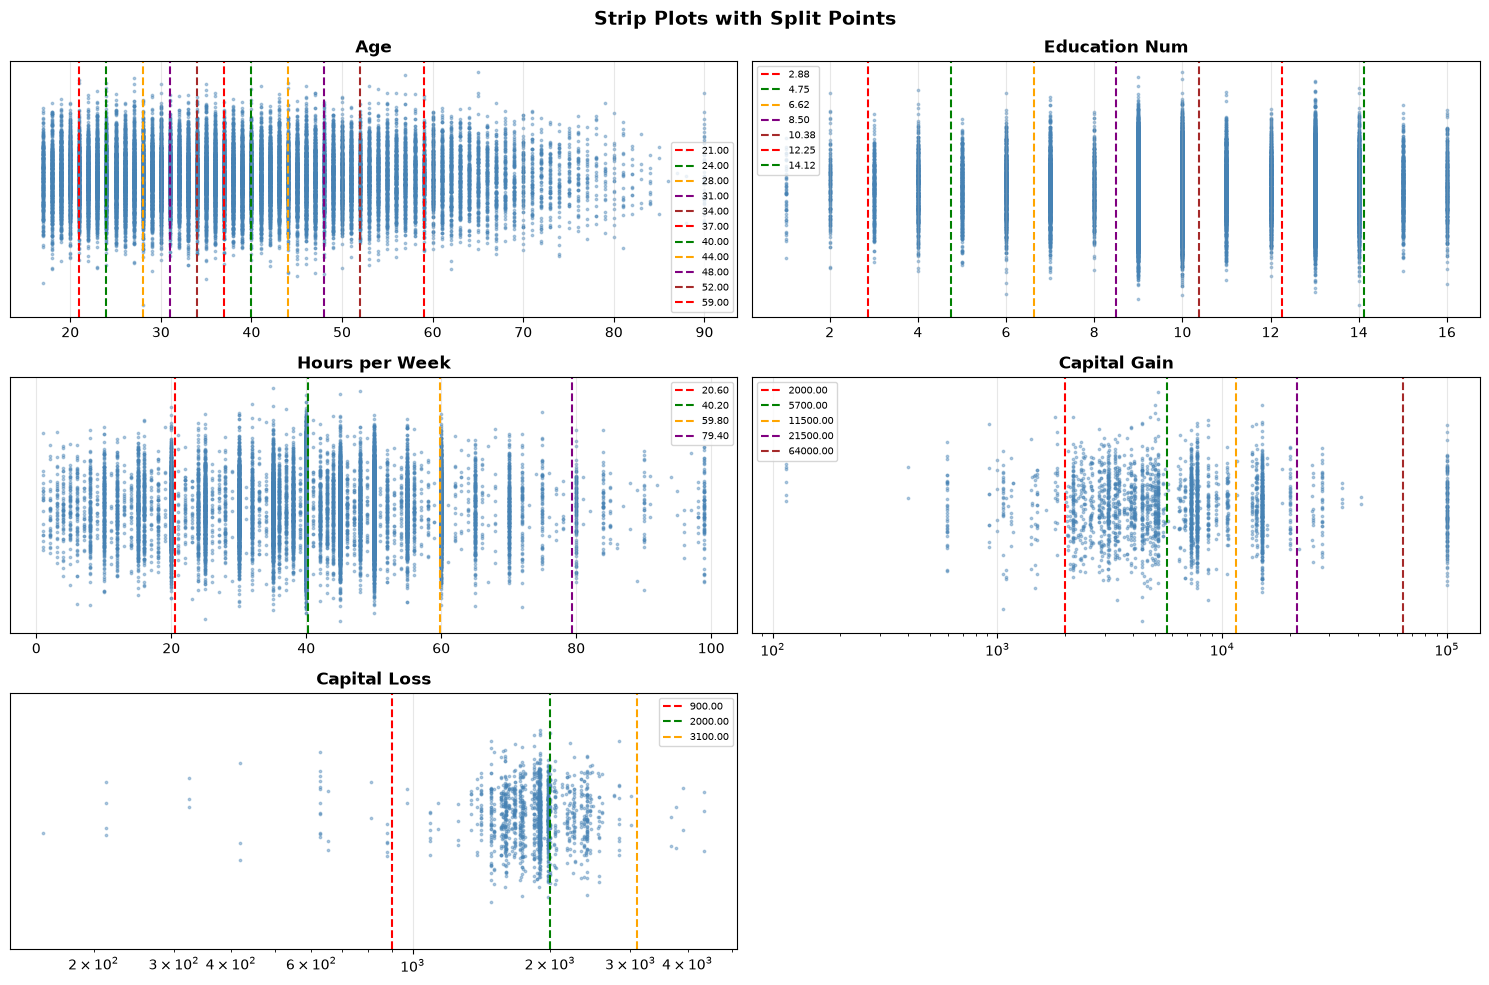

In [17]:
df = pd.read_csv("../data/adult.csv")
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
fig.suptitle('Strip Plots with Split Points', fontsize=14, fontweight='bold')

# تعریف ویژگی‌ها و split points
plots_info = {
    0: {'col': 'age', 'title': 'Age', 'splits': pd.qcut(df['age'], q=12, retbins=True, duplicates='drop')[1][1:-1]},
    1: {'col': 'education-num', 'title': 'Education Num', 'splits': pd.cut(df['education-num'], bins=8, retbins=True)[1][1:-1]},
    2: {'col': 'hours-per-week', 'title': 'Hours per Week', 'splits': pd.cut(df['hours-per-week'], bins=5, retbins=True)[1][1:-1]},
    3: {'col': 'capital-gain', 'title': 'Capital Gain', 'splits': [2000, 5700, 11500, 21500, 64000], 'log': True},
    4: {'col': 'capital-loss', 'title': 'Capital Loss', 'splits': [900, 2000, 3100], 'log': True}
}

for idx, info in plots_info.items():
    ax = axes[idx // 2, idx % 2]
    col = info['col']

    # Jitter برای محور y
    y_jitter = np.random.normal(0, 0.3, len(df))

    # رسم نقاط
    ax.scatter(df[col], y_jitter, alpha=0.4, s=3, color='steelblue')

    # مقیاس لگاریتمی
    if info.get('log'):
        ax.set_xscale('log')

    # خطوط split points
    colors = ['red', 'green', 'orange', 'purple', 'brown']
    for i, split in enumerate(info['splits']):
        ax.axvline(x=split, color=colors[i % 5], linestyle='--',
                  linewidth=1.5, label=f'{split:.2f}')

    # تنظیمات
    ax.set_title(info['title'], fontweight='bold')
    ax.set_yticks([])
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis='x')

# حذف subplot خالی
axes[2, 1].remove()

plt.tight_layout()
plt.show()